In [1]:
# Setup: Add the src folder to sys.path so that our modules are importable.
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "src")))
import pickle
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import torch

# Import modules from our package
from pre_proc.define_copulas import define_copulas
from param.generate_rvine import generate_r_samples
from pre_proc.preparation import prep_cop
from sampling.vine_sample import vine_copula_sample
from utils.tensor_op import create_points, replace_nan_inf
from classes.objects import vine_obj_bin, margin_obj
from pred.prediction import predict_vine
from info.info_estimation import vine_entropy

# For inline plots
%matplotlib inline


import numpy as np

def generate_gaussian_data(N, d, corr=0.8):
    """
    Generate a Gaussian dataset with dimension d and correlation 'corr' among all pairs.

    Args:
        N (int): number of samples
        d (int): dimension
        corr (float): correlation coefficient to use for off-diagonal entries
    Returns:
        np.ndarray of shape [N, d] with correlation ~ corr among all variable pairs.
    """
    # Build correlation matrix
    # diag=1.0, off-diag=corr
    R = (1 - corr) * np.eye(d) + corr * np.ones((d,d))
    # Enforce exact positivity (in case corr close to 1)
    # Usually 0.8 is safe, but let's do a small check
    # We can do an eigenvalue approach, but for 0< corr <1 it should be PD.
    
    mean = np.zeros(d)
    data = np.random.multivariate_normal(mean, R, size=N)
    return data

Generated sample shape: (1000, 5)


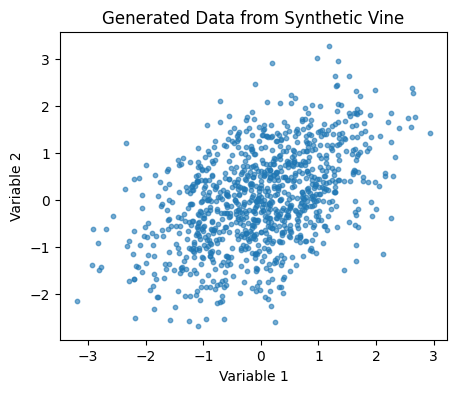

Preprocessed data shape: torch.Size([1000, 5])
Fitting vine. (Progress messages will be printed for each tree level.)
[vine_obj_bin.fit] Fitting vine tree level 0 ...
[vine_obj_bin.fit] Fitting vine tree level 1 ...
[vine_obj_bin.fit] Fitting vine tree level 2 ...
[vine_obj_bin.fit] Fitting vine tree level 3 ...
[vine_obj_bin.fit] Completed fitting.
Sampled from fitted vine shape: torch.Size([2000, 5])
Evaluated density shapes: torch.Size([100000]) torch.Size([100000])
Correlation (dim 0 vs y_em): -0.04384694003165878


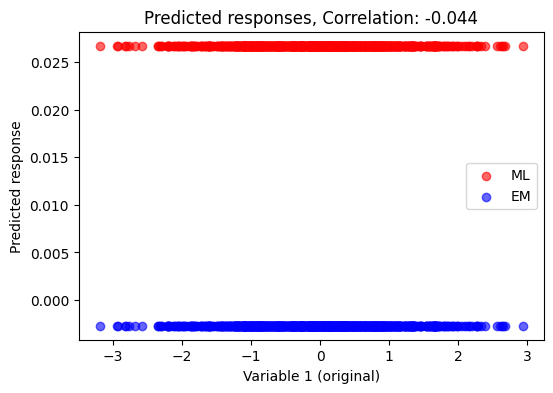

Estimated vine entropy: 7.098697185516357


In [3]:
def main():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # 1) Define vine for generating data
    cases = 1000
    vine_type = 'c-vine'  # can be 'c-vine', 'd-vine', or 'r-vine'
    method = 'matrix'
    binning = False
    n_bin = 3
    dim = 5

    # Define vine structure and margins for simulation
    r_matrix, cop_vine, ind_vine, nodes, matrix_edges, margin_vine = define_copulas(vine_type, method, binning, n_bin, dim)
    sample_, v, v_flip, tau_corr, tau_bins = generate_r_samples(cases, r_matrix, ind_vine, nodes, margin_vine, cop_vine, n_bin, binning)
    sample = generate_gaussian_data(cases, dim, corr=0.5)

    print("Generated sample shape:", sample.shape)
    
    # Plot generated data (first two dimensions)
    plt.figure(figsize=(5,4))
    plt.scatter(sample[:,0], sample[:,1], s=10, alpha=0.6)
    plt.title("Generated Data from Synthetic Vine")
    plt.xlabel("Variable 1")
    plt.ylabel("Variable 2")
    plt.show()

    # 2) (Optional) Load data from file (skipped here)
    load_mat = False
    load_pickle = False
    if load_mat:
        mat_contents = sio.loadmat('stu_ex_01.mat')
        dat = mat_contents.get('x')
        sample = torch.tensor(dat, dtype=torch.float32)
    if load_pickle:
        with open("clay_20_ale", "rb") as f:
            dict_save = pickle.load(f)
            vine_copulas = dict_save["vine_copulas"]
            x = dict_save["data"]
            r_matrix = dict_save["r_matrix"]
            vine_depth = 20
            sample = torch.tensor(x, dtype=torch.float32)
    
    # 3) Define vine for fitting.
    vine_depth = dim
    margin_list = [margin_obj('norm', [0.0, 1.0], True) for _ in range(vine_depth)]
    knots = 50
    vine = vine_obj_bin(vine_type, "kercop", vine_depth, margin_list, knots, method, r_matrix)
    # Print progress during fitting: modify the fit() method to print each tree level.
    x_data = torch.tensor(sample, dtype=torch.float32, device=device).clone().detach()
    
    # 4) Preprocess data
    sort_n = 'rand'
    x_prep = prep_cop(x_data, vine, sort_n)
    print("Preprocessed data shape:", x_prep.shape)
    
    # 5) Fit the vine model.
    gen_dict = {'parallel': True, 'binning': binning, 'param': False, 'vine_depth': vine_depth, 'fitted': False}
    par_dict = {'param_families': ["ind", "gaussian"]}
    npc_dict = {'opt_method': 'LL1', 'batch_paral': 3}
    bin_dict = {'n_bin': n_bin}
    print("Fitting vine. (Progress messages will be printed for each tree level.)")
    vine.fit(x_prep, gen_dict, npc_dict, par_dict, bin_dict)
    
    # 6) Sample from the fitted vine.
    samp_fit = vine_copula_sample(vine, 2000)
    print("Sampled from fitted vine shape:", samp_fit.shape)
    
    # 7) Evaluate the vine density.
    exp_dim = 100
    dim_col = 0
    pts = create_points(x_prep, dim_col, exp_dim)
    p, p_cop, logf = vine.evaluation(pts)
    print("Evaluated density shapes:", p.shape, p_cop.shape)
    
    # 8) Predict using the vine model.
    p_pred, y_ml, y_em = predict_vine(x_prep, vine, dim_col, exp_dim)
    y_em = replace_nan_inf(y_em)
    x_col = x_prep[:, dim_col].cpu().numpy()
    y_em_np = y_em.cpu().numpy()
    corr = np.corrcoef(x_col, y_em_np)[0, 1]
    print("Correlation (dim 0 vs y_em):", corr)
    
    plt.figure(figsize=(6,4))
    plt.scatter(x_col, y_ml.cpu().numpy(), c='r', label='ML', alpha=0.6)
    plt.scatter(x_col, y_em_np, c='b', label='EM', alpha=0.6)
    plt.title(f"Predicted responses, Correlation: {corr:.3f}")
    plt.xlabel("Variable 1 (original)")
    plt.ylabel("Predicted response")
    plt.legend()
    plt.show()
    
    # 9) Estimate the mutual information / entropy.
    info_dict = {'cases': 1000, 'iterations': 10, 'alpha': 0.05}
    H = vine_entropy(vine, info_dict)
    print("Estimated vine entropy:", H)
    
    return x_prep, samp_fit

# Run the experiment
x_prep, samp_fit = main()

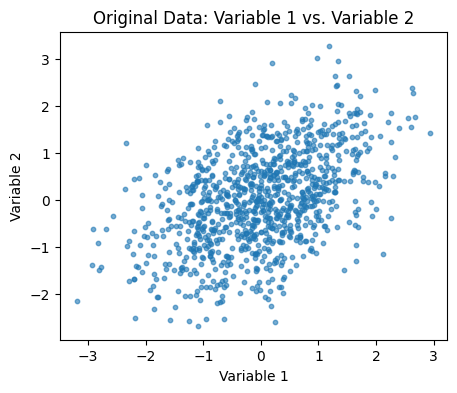

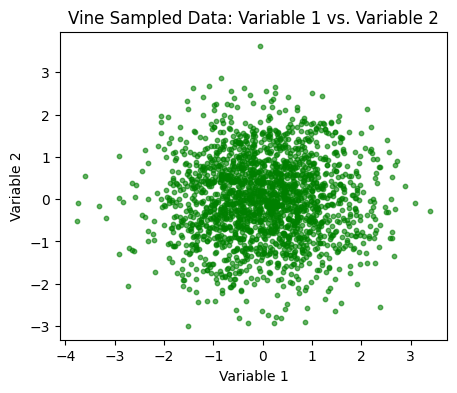

In [4]:
# Visualize pairs: Original data (first two dimensions) and samples generated by the fitted vine

# Assume x_prep and samp_fit are available from the previous cell.
# Plot original data pair (dim0 vs. dim1)
plt.figure(figsize=(5,4))
plt.scatter(x_prep[:,0].cpu().numpy(), x_prep[:,1].cpu().numpy(), s=10, alpha=0.6)
plt.title("Original Data: Variable 1 vs. Variable 2")
plt.xlabel("Variable 1")
plt.ylabel("Variable 2")
plt.show()

# Plot sampled data pair (first two dimensions)
plt.figure(figsize=(5,4))
plt.scatter(samp_fit[:,0].cpu().numpy(), samp_fit[:,1].cpu().numpy(), s=10, alpha=0.6, color='green')
plt.title("Vine Sampled Data: Variable 1 vs. Variable 2")
plt.xlabel("Variable 1")
plt.ylabel("Variable 2")
plt.show()